In [10]:
! pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/69.5 MB 1.1 MB/s eta 0:01:04
   ---------------------------------------- 0.8/69.5 MB 1.1 MB/s eta 0:01:04
    --------------------------------------- 1.0/69.5 MB 1.3 MB/s eta 0:00:54
    --------------------------------------- 1.3/69.5 MB 1.1 MB/s eta 0:01:00
    --------------------------------------- 1.6/69.5 MB 1.2 MB/s eta 0:00:58
   - -------------------------------------- 1.8/69.5 MB 1.1 MB/s eta 0:01:01
   - -------------------------------------- 2.1/69.5 MB 1.2 MB/s eta 0:00:57
   - -------------------------------------- 2.6/69.5 MB 1.3 MB/s eta 0:00:52
   - -----------------------------

In [19]:
# Importing core libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importing preprocessing tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Importing the Machine Learning Algorithms
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge, Lasso 
from xgboost import XGBRegressor

# Importing Evaluation Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [20]:
# Load the dataset
df = pd.read_csv('car data.csv')

# Display the first 5 rows 
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [21]:
# Null Handling
print("Checking for missing values initially:\n", df.isnull().sum())

# Automatically fill numerical columns with their median
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# Automatically fill categorical columns with their mode
for col in df.select_dtypes(include=['object']).columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print("\nAll potential missing values have been securely handled.")

Checking for missing values initially:
 Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

All potential missing values have been securely handled.


In [22]:
# Feature Engineering
# Engineer a 'Car_Age' feature instead from age.
df['Car_Age'] = 2026 - df['Year']

# The 'Car_Name' is too unique and creates too much noise, so we drop it.
# We also drop the original 'Year' column since we now have 'Car_Age'.
df.drop(['Car_Name', 'Year'], axis=1, inplace=True)

print("Features after engineering:")
print(df.columns)

Features after engineering:
Index(['Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type',
       'Seller_Type', 'Transmission', 'Owner', 'Car_Age'],
      dtype='object')


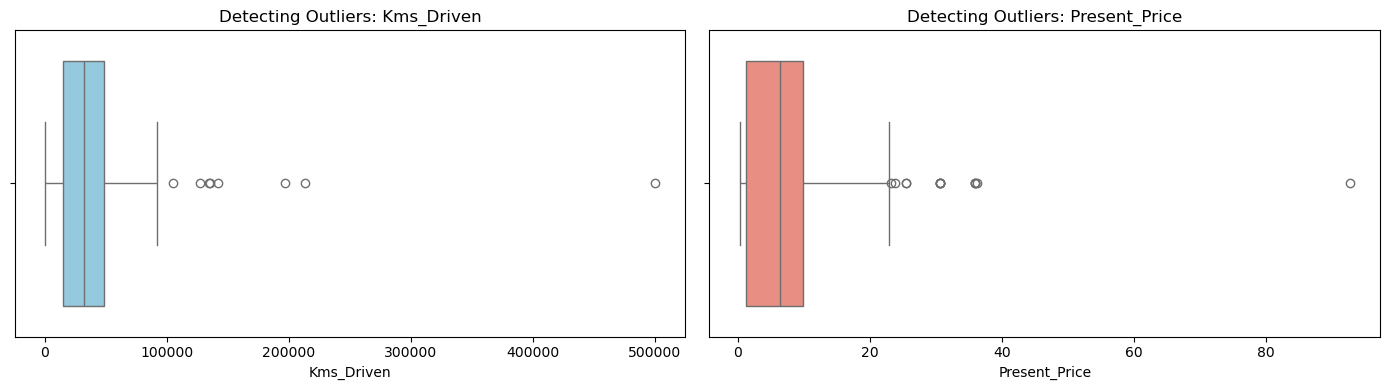

In [23]:
# Visualizing Outliers in Continuous Numerical Features
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Boxplot for Kms_Driven
sns.boxplot(x=df['Kms_Driven'], ax=axes[0], color='skyblue')
axes[0].set_title('Detecting Outliers: Kms_Driven')

# Boxplot for Present_Price
sns.boxplot(x=df['Present_Price'], ax=axes[1], color='salmon')
axes[1].set_title('Detecting Outliers: Present_Price')

plt.tight_layout()
plt.show()

In [24]:
# Outlier Removal using IQR for both continuous features

# --- IQR for Kms_Driven ---
Q1_kms = df['Kms_Driven'].quantile(0.25)
Q3_kms = df['Kms_Driven'].quantile(0.75)
IQR_kms = Q3_kms - Q1_kms
upper_kms = Q3_kms + 1.5 * IQR_kms
lower_kms = Q1_kms - 1.5 * IQR_kms

# --- IQR for Present_Price ---
Q1_price = df['Present_Price'].quantile(0.25)
Q3_price = df['Present_Price'].quantile(0.75)
IQR_price = Q3_price - Q1_price
upper_price = Q3_price + 1.5 * IQR_price
lower_price = Q1_price - 1.5 * IQR_price

# Filtering out rows that fall outside the IQR bounds for either feature
df_clean = df[
    (df['Kms_Driven'] >= lower_kms) & (df['Kms_Driven'] <= upper_kms) &
    (df['Present_Price'] >= lower_price) & (df['Present_Price'] <= upper_price)
].copy()

print(f"Original dataset rows: {df.shape[0]}")
print(f"Cleaned dataset rows:  {df_clean.shape[0]}")

Original dataset rows: 301
Cleaned dataset rows:  282


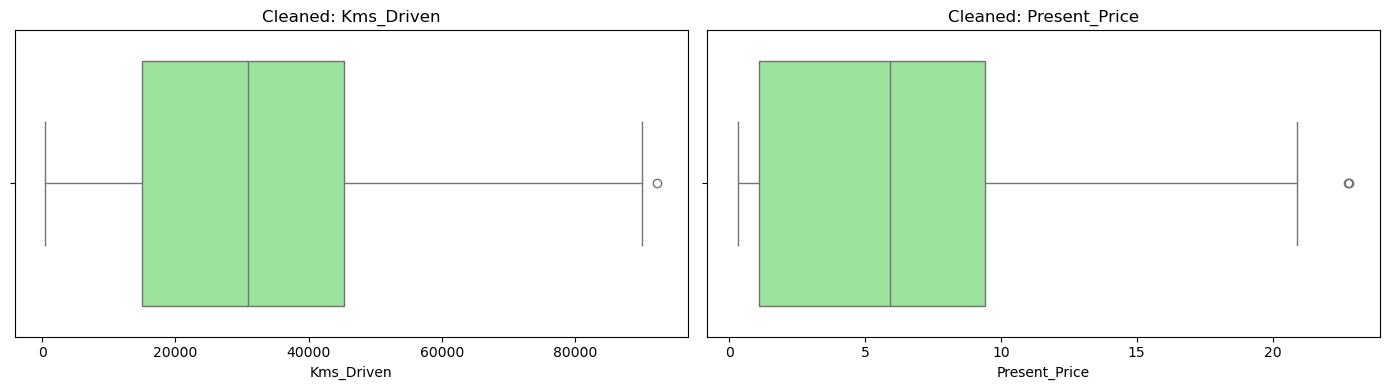

In [25]:
# Visualizing Distribution AFTER Outlier Removal
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(x=df_clean['Kms_Driven'], ax=axes[0], color='lightgreen')
axes[0].set_title('Cleaned: Kms_Driven')

sns.boxplot(x=df_clean['Present_Price'], ax=axes[1], color='lightgreen')
axes[1].set_title('Cleaned: Present_Price')

plt.tight_layout()
plt.show()

In [26]:
# One-Hot Encoding for Categorical Columns
# Convert text columns (Fuel_Type, Seller_Type, Transmission) to binary 0/1 columns
df_encoded = pd.get_dummies(df_clean, drop_first=True)

print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Shape after encoding: (282, 9)


,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,False,True,False,True
1,4.75,9.54,43000,0,13,True,False,False,True
2,7.25,9.85,6900,0,9,False,True,False,True
3,2.85,4.15,5200,0,15,False,True,False,True
4,4.60,6.87,42450,0,12,True,False,False,True


In [27]:
# Splitting Features & Target + Feature Scaling
X = df_encoded.drop('Selling_Price', axis=1)
y = df_encoded['Selling_Price']

# Split into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features (Mean=0, StdDev=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data scaled and split successfully!")

Data scaled and split successfully!


In [28]:
# Training & Evaluating Multiple ML Algorithms
models = {
    "Linear Regression": LinearRegression(),
    "Ridge (L2)": Ridge(alpha=1.0),
    "Lasso (L1)": Lasso(alpha=0.1),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5),
    "SVR": SVR(kernel='rbf'),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42) # The new addition
}

results = []

for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)
    
    r2 = r2_score(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)
    
    results.append({
        "Model": model_name,
        "R-Squared": round(r2, 4),
        "RMSE": round(rmse, 4),
        "MAE": round(mae, 4)
    })

print("Training complete! All 7 models have been evaluated.")

Training complete! All 7 models have been evaluated.


--- ML Algorithm Performance Comparison ---


,Model,R-Squared,RMSE,MAE
0,Linear Regression,0.8448,1.2079,0.9153
1,Ridge (L2),0.8448,1.2079,0.9158
2,Lasso (L1),0.8377,1.2350,0.9332
3,KNN Regressor,0.9109,0.9153,0.5946
4,SVR,0.8743,1.0869,0.5914
5,Random Forest,0.9703,0.5286,0.3867
6,XGBoost,0.9588,0.6221,0.4254


C:\Users\Admin\AppData\Local\Temp\ipykernel_11952\1170680932.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R-Squared', y='Model',legend=False, data=comparison_df, palette='magma')


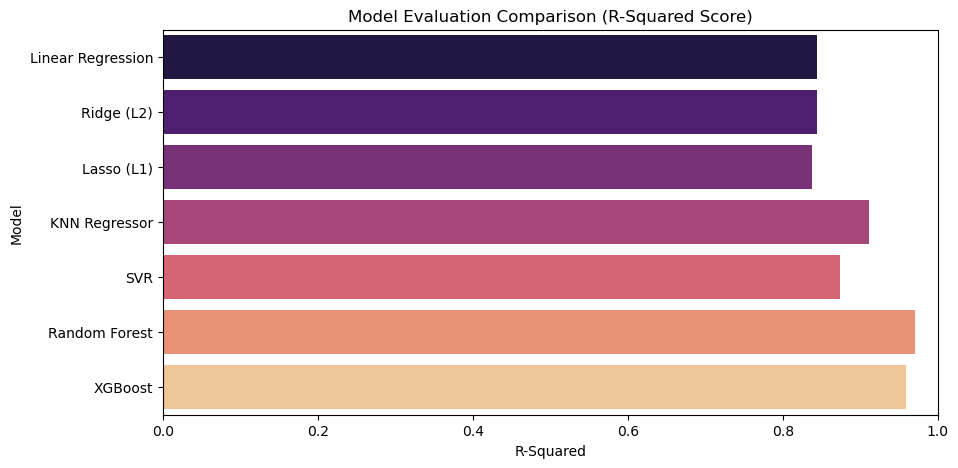

In [35]:
# Algorithm Comparison Table & Visualization
# Convert the results into a Pandas DataFrame
comparison_df = pd.DataFrame(results)

print("--- ML Algorithm Performance Comparison ---")
display(comparison_df) 

# Plotting performance visually
plt.figure(figsize=(10, 5))
sns.barplot(x='R-Squared', y='Model',legend=False, data=comparison_df, palette='magma')
plt.title('Model Evaluation Comparison (R-Squared Score)')
plt.xlim(0, 1)
plt.show()

In [38]:
# Interactive Car Price Prediction Application
import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names") # Extra safety net

# We select Random Forest as it yielded the best R-Squared and lowest errors
best_model = models["Random Forest"]

print("--- Used Car Price Predictor ---")
try:
    # Gather User Inputs
    year = int(input("Enter Manufacture Year (e.g., 2017): "))
    present_price = float(input("Enter Present Showroom Price in Lakhs (e.g., 8.5): "))
    kms_driven = int(input("Enter Kilometers Driven (e.g., 35000): "))
    fuel = input("Enter Fuel Type (Petrol/Diesel/CNG): ").strip().title()
    seller = input("Enter Seller Type (Dealer/Individual): ").strip().title()
    transmission = input("Enter Transmission (Manual/Automatic): ").strip().title()
    owner = int(input("Enter Number of Previous Owners (0, 1, 2): "))

    # Feature Engineering
    car_age = 2026 - year
    fuel_diesel = 1 if fuel == 'Diesel' else 0
    fuel_petrol = 1 if fuel == 'Petrol' else 0
    seller_individual = 1 if seller == 'Individual' else 0
    trans_manual = 1 if transmission == 'Manual' else 0

    # Create the final feature array
    user_input = np.array([[
        present_price, kms_driven, owner, car_age, 
        fuel_diesel, fuel_petrol, seller_individual, trans_manual
    ]])

    user_input_df = pd.DataFrame(user_input, columns=X.columns)

    # Scale the user input DataFrame
    user_input_scaled = scaler.transform(user_input_df)

    # Make the Prediction
    predicted_val = best_model.predict(user_input_scaled)[0]

    print("\n" + "="*45)
    print(f"Estimated Selling Price: {predicted_val:.2f} Lakhs")
    print("="*45)

except Exception as e:
    print(f"\nError: Please ensure valid values were entered. Detail: {e}")

--- Used Car Price Predictor ---


Enter Manufacture Year (e.g., 2017):  2023
Enter Present Showroom Price in Lakhs (e.g., 8.5):  15
Enter Kilometers Driven (e.g., 35000):  5000
Enter Fuel Type (Petrol/Diesel/CNG):  Petrol
Enter Seller Type (Dealer/Individual):  Individual
Enter Transmission (Manual/Automatic):  Automatic
Enter Number of Previous Owners (0, 1, 2):  0



Estimated Selling Price: 14.64 Lakhs
